In [6]:
import numpy as np
import matplotlib.pyplot as plt

from iqwav.modulation import (
    bpsk_modulate,
    qpsk_modulate,
    bpsk_waveform,
    qpsk_waveform,
)

from iqwav.demod import (
    bpsk_demodulate,
    qpsk_demodulate,
)

from iqwav.dsp import add_awgn

In [7]:
bits = np.array([0, 1, 1, 0, 1, 0, 0, 1])

print("Bits:")
print(bits)

Bits:
[0 1 1 0 1 0 0 1]


In [8]:
bpsk_symbols = bpsk_modulate(bits)

print("BPSK symbols:")
print(bpsk_symbols)

BPSK symbols:
[ 1.+0.j -1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j -1.+0.j]


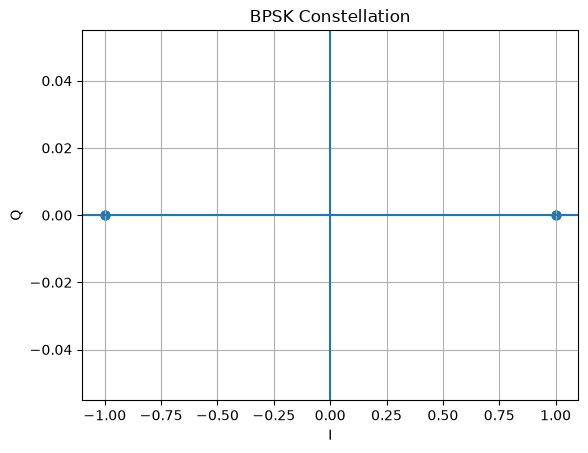

In [9]:
plt.scatter(
    bpsk_symbols.real,
    bpsk_symbols.imag
)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("BPSK Constellation")
plt.grid()

plt.show()

In [10]:
qpsk_symbols = qpsk_modulate(bits)

print("QPSK symbols:")
print(qpsk_symbols)

QPSK symbols:
[-0.70710678+0.70710678j  0.70710678-0.70710678j  0.70710678-0.70710678j
 -0.70710678+0.70710678j]


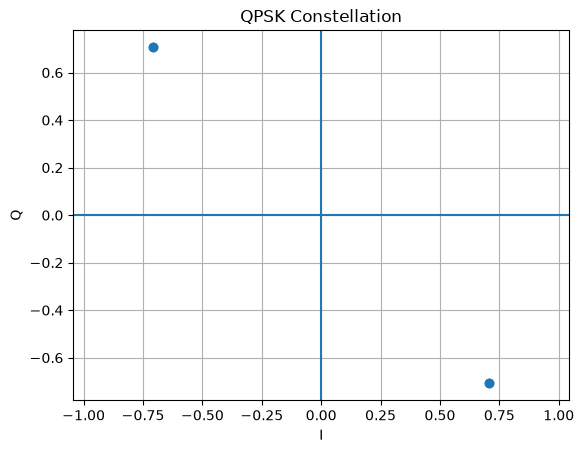

In [11]:
plt.scatter(
    qpsk_symbols.real,
    qpsk_symbols.imag
)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("QPSK Constellation")
plt.grid()

plt.axis("equal")
plt.show()

In [12]:
sps = 10

bpsk_samples = bpsk_waveform(bits, sps)

print("Number of bits:", len(bits))
print("Samples per symbol:", sps)
print("Total waveform samples:", len(bpsk_samples))

print("\nFirst 30 samples:")
print(bpsk_samples[:30])

Number of bits: 8
Samples per symbol: 10
Total waveform samples: 80

First 30 samples:
[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j
  1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j
 -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j
 -1.+0.j -1.+0.j -1.+0.j]


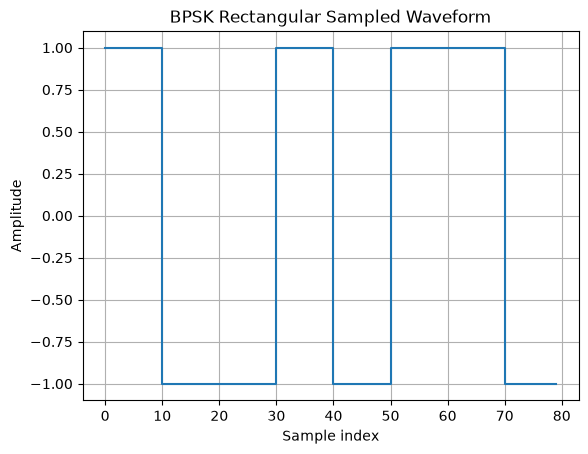

In [13]:
plt.step(
    np.arange(len(bpsk_samples)),
    bpsk_samples.real,
    where="post"
)

plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("BPSK Rectangular Sampled Waveform")
plt.grid()

plt.show()

In [14]:
qpsk_samples = qpsk_waveform(bits, sps)

print("Number of bits:", len(bits))
print("Number of QPSK symbols:", len(bits) // 2)
print("Samples per symbol:", sps)
print("Total waveform samples:", len(qpsk_samples))

Number of bits: 8
Number of QPSK symbols: 4
Samples per symbol: 10
Total waveform samples: 40


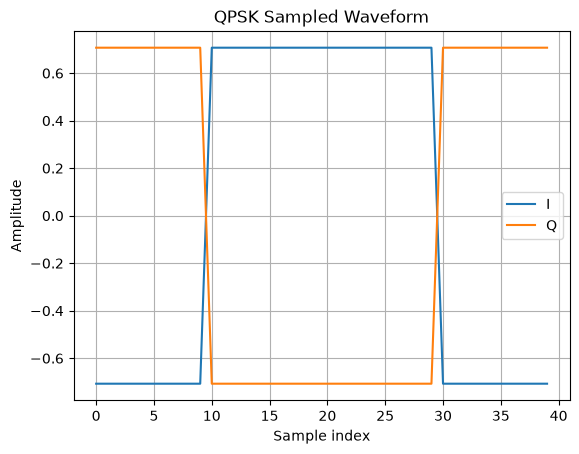

In [15]:
plt.plot(qpsk_samples.real, label="I")
plt.plot(qpsk_samples.imag, label="Q")

plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("QPSK Sampled Waveform")

plt.legend()
plt.grid()

plt.show()

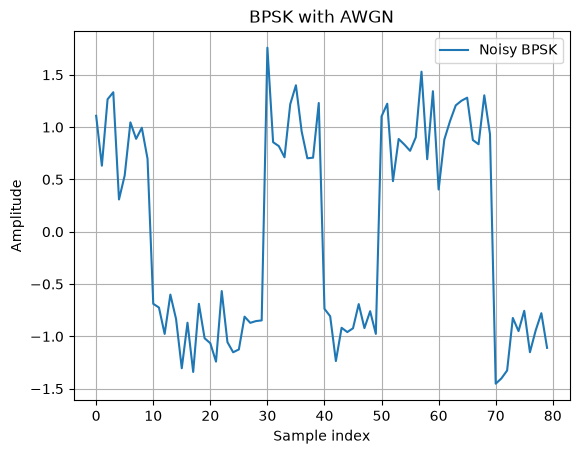

In [16]:
rng = np.random.default_rng(42)

bpsk_noisy = add_awgn(
    bpsk_samples,
    snr_db=6,
    rng=rng
)

plt.plot(
    bpsk_noisy.real,
    label="Noisy BPSK"
)

plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("BPSK with AWGN")
plt.grid()
plt.legend()

plt.show()

In [17]:
bpsk_recovered = bpsk_demodulate(
    bpsk_noisy,
    samples_per_symbol=sps
)

print("Original bits:")
print(bits)

print("\nRecovered bits:")
print(bpsk_recovered)

print("\nCorrect:")
print(np.array_equal(bits, bpsk_recovered))

Original bits:
[0 1 1 0 1 0 0 1]

Recovered bits:
[0 1 1 0 1 0 0 1]

Correct:
True


In [18]:
rng = np.random.default_rng(42)

qpsk_noisy = add_awgn(
    qpsk_samples,
    snr_db=6,
    rng=rng
)

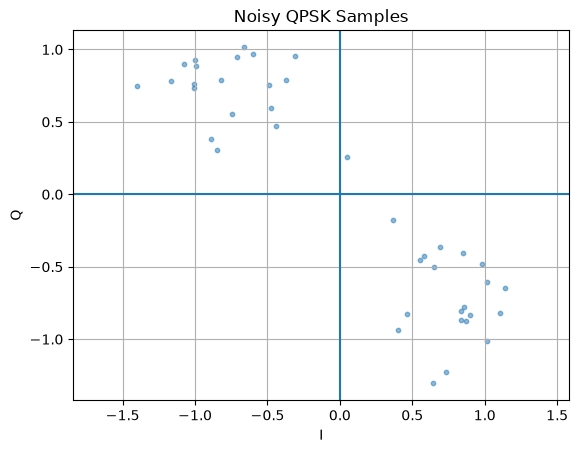

In [19]:
plt.scatter(
    qpsk_noisy.real,
    qpsk_noisy.imag,
    s=10,
    alpha=0.5
)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("Noisy QPSK Samples")

plt.axis("equal")
plt.grid()

plt.show()

In [20]:
qpsk_recovered = qpsk_demodulate(
    qpsk_noisy,
    samples_per_symbol=sps
)

print("Original bits:")
print(bits)

print("\nRecovered bits:")
print(qpsk_recovered)

print("\nCorrect:")
print(np.array_equal(bits, qpsk_recovered))

Original bits:
[0 1 1 0 1 0 0 1]

Recovered bits:
[0 1 1 0 1 0 0 1]

Correct:
True


In [21]:
print("BPSK recovered correctly:",
      np.array_equal(bits, bpsk_recovered))

print("QPSK recovered correctly:",
      np.array_equal(bits, qpsk_recovered))

BPSK recovered correctly: True
QPSK recovered correctly: True
